In [1]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.linalg import logm, expm
import random

In [2]:
# butterfly attractor (ground truth)
class ChaosAttractors():
    """
    Initial conditions for the systems to display chaotic behaviour are
    defined as follows:
    Lorenz 63 -> s = 10, r = 8/3, b = 28 and dt = 0.01
    """
    def __init__(self, steps, lrz_s=10, lrz_r=28, lrz_b=8/3, lrz_dt = 0.01,
                 rab_fab_a = 0.14, rab_fab_g = 0.1, rab_fab_dt = 0.01,
                 ros_a=0.2, ros_b=0.2, ros_c=6.3, ros_dt = 0.01):
        self.lrz_s = lrz_s
        self.lrz_b = lrz_b
        self.lrz_r = lrz_r
        self.lrz_dt = lrz_dt
        self.rab_fab_a = rab_fab_a
        self.rab_fab_g = rab_fab_g
        self.rab_fab_dt = rab_fab_dt
        self.ros_a = ros_a
        self.ros_b = ros_b
        self.ros_c = ros_c
        self.ros_dt = ros_dt
        self.steps = steps

    """Lorenz 63 System"""
    def lorenz63(self):
        xs = np.empty((self.steps + 1,))
        ys = np.empty((self.steps + 1,))
        zs = np.empty((self.steps + 1,))

        xs[0], ys[0], zs[0] = (1.0, 1.0, 1.0)
        for i in range(self.steps):
            x_dot = self.lrz_s*(ys[i] - xs[i])
            y_dot = self.lrz_r*xs[i] - ys[i] - xs[i]*zs[i]
            z_dot = xs[i]*ys[i] - self.lrz_b*zs[i]
            xs[i + 1] = xs[i] + (x_dot * self.lrz_dt)
            ys[i + 1] = ys[i] + (y_dot * self.lrz_dt)
            zs[i + 1] = zs[i] + (z_dot * self.lrz_dt)
        return xs, ys, zs


In [3]:
# Define length of the chaotic time series
attractors_series  = ChaosAttractors(10000)
# Obtain the time series for the Lorenz systems
lorenz_x, lorenz_y, lorenz_z = attractors_series.lorenz63()

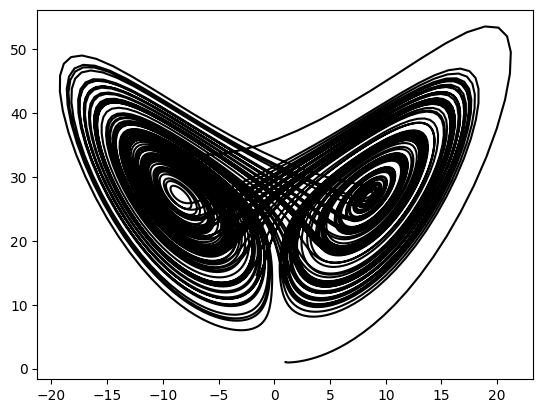

In [4]:
plt.figure()
plt.plot(lorenz_x,lorenz_z,'k-')
plt.savefig("Butterfly1.png", dpi=300, bbox_inches='tight', transparent=True)

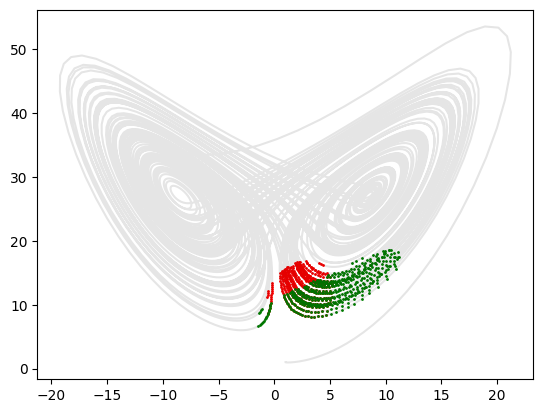

In [14]:
x_red    = 10
z_ref    = 10
distance = (lorenz_x - x_red)**2+(lorenz_z - z_ref)**2+(lorenz_y-0)**2
posi     = np.array(np.where(distance<np.percentile((lorenz_x - x_red)**2+(lorenz_z - z_ref)**2+(lorenz_y-0)**2,5)))
posi     = np.array([x for x in posi.T if x+10 <= 10000]).T
cord_t0  = np.vstack((lorenz_x[posi],lorenz_y[posi],lorenz_z[posi]))
cord_t1  = np.vstack((lorenz_x[posi+10],lorenz_y[posi+10],lorenz_z[posi+10]))

plt.figure()
plt.plot(lorenz_x,lorenz_z,'k-',alpha=0.1)
plt.scatter(cord_t0[0,:],cord_t0[2,:],color='red',s=1)
plt.scatter(cord_t1[0,:],cord_t1[2,:],color='green',s=1)
plt.savefig("Butterfly2.png", dpi=300, bbox_inches='tight', transparent=True)

[1.9618545  1.22698357 0.67673019]
[[-0.4379771  -0.46034668  0.05519796]
 [-0.73340226 -0.54351223  0.03815081]
 [-0.51990113 -0.70190839  0.99774631]]


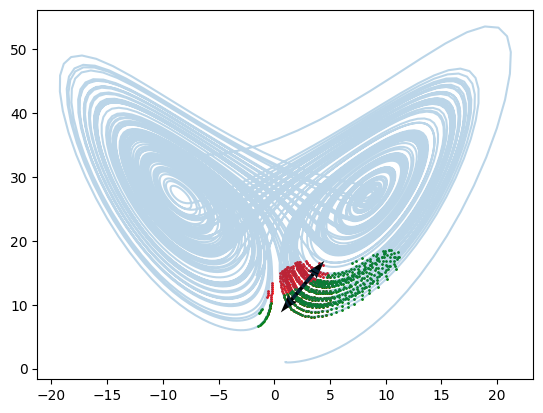

In [15]:
G   = cord_t1.dot(cord_t0.T).dot(np.linalg.inv(cord_t0.dot(cord_t0.T)))
v,m = np.linalg.eig(G)
idx = v.argsort()[::-1]
v   = v[idx]
m   = m[:,idx]

print(v)
print(m)
plt.figure()
plt.plot(lorenz_x,lorenz_z,alpha=0.3)
plt.scatter(cord_t0[0,:],cord_t0[2,:],color='red',s=1)
plt.scatter(cord_t1[0,:],cord_t1[2,:],color='green',s=1)

plt.quiver(cord_t0[0,:].mean(),cord_t0[2,:].mean(), m[0,0], m[2,0], scale=10)
plt.quiver(cord_t0[0,:].mean(),cord_t0[2,:].mean(), -m[0,0], -m[2,0], scale=10)



In [7]:
m_tmp   = m[:,0].reshape([3,1])
final_m = G.dot(m_tmp)
final_m.T.dot(final_m)/(m_tmp.T.dot(m_tmp))

array([[3.73152376]])

[28.31427415  0.47451939  0.19750714]
[[-0.28745581  0.29677161 -0.91065678]
 [-0.90908318 -0.38388922  0.16185441]
 [-0.30155752  0.87438875  0.38014126]]


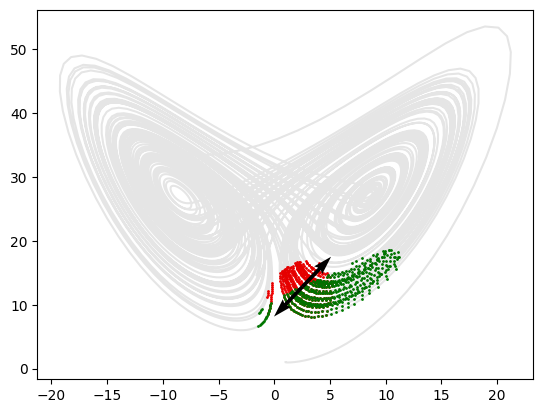

In [16]:


G   = cord_t1.dot(cord_t0.T).dot(np.linalg.inv(cord_t0.dot(cord_t0.T)))
v,m = np.linalg.eig(G.dot(G.T))
idx = v.argsort()[::-1]
v   = v[idx]
m   = m[:,idx]

print(v)
print(m)
plt.figure()
plt.plot(lorenz_x,lorenz_z,'k-',alpha=0.1)
plt.scatter(cord_t0[0,:],cord_t0[2,:],color='red',s=1)
plt.scatter(cord_t1[0,:],cord_t1[2,:],color='green',s=1)

plt.quiver(cord_t0[0,:].mean(),cord_t0[2,:].mean(), m[0,0], m[2,0], scale=5)
plt.quiver(cord_t0[0,:].mean(),cord_t0[2,:].mean(), -m[0,0], -m[2,0], scale=5)
plt.savefig("Butterfly3.png", dpi=300, bbox_inches='tight', transparent=True)

In [10]:
print(v)

[3.76637247 0.61412861 0.0464314 ]


In [9]:
m[0,0], m[1,0], m[2,0]

(np.float64(0.4964118390588053),
 np.float64(0.8680833003857457),
 np.float64(-0.0025825633866389864))

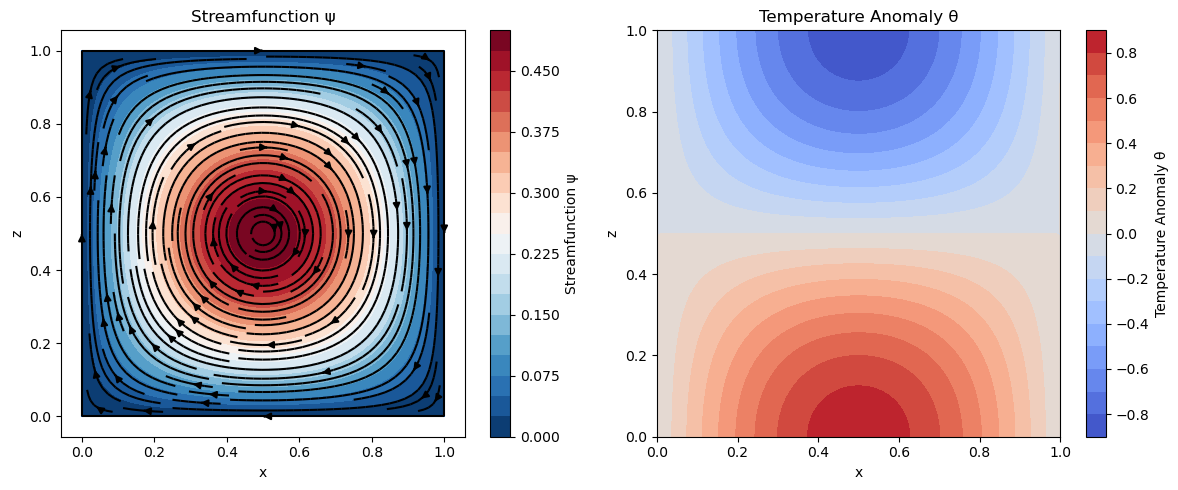

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Grid
x = np.linspace(0, 1, 100)
z = np.linspace(0, 1, 100)
X, Z = np.meshgrid(x, z)

# Lorenz state input
x_lorenz,y_lorenz,z_lorenz = m[0,0], m[1,0], m[2,0]
# y_lorenz = 0.868083300385746
# z_lorenz = -0.002582563386639414

# Construct fields
psi  = x_lorenz * np.sin(np.pi * X) * np.sin(np.pi * Z)
theta = y_lorenz * np.sin(np.pi * X) * np.cos(np.pi * Z) + z_lorenz * np.sin(2 * np.pi * Z)

# Plot
plt.figure(figsize=(12, 5))

# Streamfunction
plt.subplot(1, 2, 1)
cf1 = plt.contourf(X, Z, psi, cmap='RdBu_r', levels=20)
plt.colorbar(cf1, label='Streamfunction ψ')
plt.streamplot(X, Z, -np.gradient(psi, axis=0), np.gradient(psi, axis=1), color='k', density=1.5)
plt.title('Streamfunction ψ')
plt.xlabel('x')
plt.ylabel('z')

# Temperature
plt.subplot(1, 2, 2)
cf2 = plt.contourf(X, Z, theta, cmap='coolwarm', levels=20)
plt.colorbar(cf2, label='Temperature Anomaly θ')
plt.title('Temperature Anomaly θ')
plt.xlabel('x')
plt.ylabel('z')

plt.tight_layout()

plt.savefig("Butterfly4.png", dpi=300, bbox_inches='tight', transparent=True)

plt.show()


In [ ]:
m_tmp   = m[:,0].reshape([3,1])
final_m = G.dot(m_tmp)
final_m.T.dot(final_m)/(m_tmp.T.dot(m_tmp))

array([[12.87769927]])

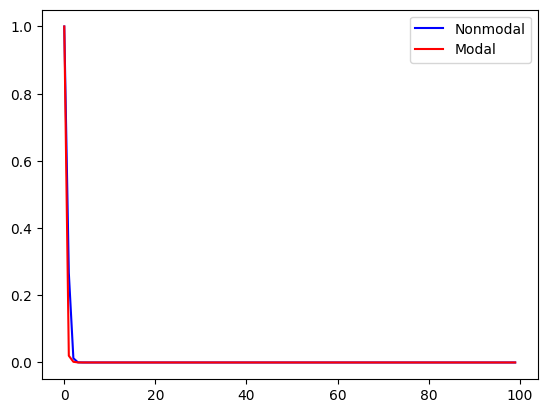

In [ ]:
#s = np.random.normal(0, 0.1, 1000)
dim      = 100
growth1  = np.zeros((dim,1))
growth2  = np.zeros((dim,1))
a        = np.array([[0.1,0.5],[-0.1,0.9]])
x_0      = np.array([[1],[0]])
for tau in range(0,dim):
    G_tau    = np.linalg.matrix_power(a, tau)
    x_tau    = np.matmul(G_tau,x_0)
    h        = np.matmul(np.matrix(G_tau).getH(),G_tau)
    w,v      = np.linalg.eig(h)
    growth1[tau,:] = np.max(w)
    growth2[tau,:] = np.matmul(np.transpose(x_tau),x_tau)/np.matmul(np.transpose(x_0),x_0)

plt.figure()
plt.plot(growth1,'b', label='Nonmodal')
plt.plot(growth2,'r', label='Modal')
plt.legend()

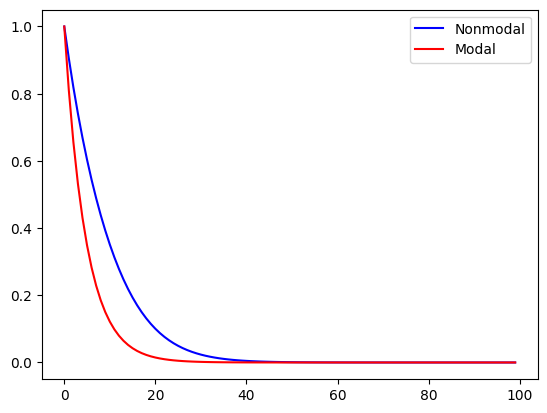

In [18]:
#s = np.random.normal(0, 0.1, 1000)
dim      = 100
growth1  = np.zeros((dim,1))
growth2  = np.zeros((dim,1))
a        = np.array([[0.9,0.1],[0.,0.9]])
x_0      = np.array([[1],[0]])
for tau in range(0,dim):
    G_tau    = np.linalg.matrix_power(a, tau)
    x_tau    = np.matmul(G_tau,x_0)
    h        = np.matmul(np.matrix(G_tau).getH(),G_tau)
    w,v      = np.linalg.eig(h)
    growth1[tau,:] = np.max(w)
    growth2[tau,:] = np.matmul(np.transpose(x_tau),x_tau)/np.matmul(np.transpose(x_0),x_0)

plt.figure()
plt.plot(growth1,'b', label='Nonmodal')
plt.plot(growth2,'r', label='Modal')
plt.legend()